<a href="https://colab.research.google.com/github/hayaalnaal2002-debug/Arabic_handwritten_characters/blob/main/Experiment1_FS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip '/content/drive/MyDrive/Colab Notebooks/experience 1.zip'

Streaming output truncated to the last 5000 lines.
  inflating: experience 1/Group i/Alf_Isolated/AHCR_00033_Alf_Isolated_15.jpg  
  inflating: experience 1/Group i/Alf_Isolated/AHCR_00033_Alf_Isolated_6.jpg  
  inflating: experience 1/Group i/Alf_Isolated/AHCR_00033_Alf_Isolated_7.jpg  
  inflating: experience 1/Group i/Alf_Isolated/AHCR_00034_Alf_Isolated_14.jpg  
  inflating: experience 1/Group i/Alf_Isolated/AHCR_00034_Alf_Isolated_15.jpg  
  inflating: experience 1/Group i/Alf_Isolated/AHCR_00034_Alf_Isolated_6.jpg  
  inflating: experience 1/Group i/Alf_Isolated/AHCR_00034_Alf_Isolated_7.jpg  
  inflating: experience 1/Group i/Alf_Isolated/AHCR_00035_Alf_Isolated_14.jpg  
  inflating: experience 1/Group i/Alf_Isolated/AHCR_00035_Alf_Isolated_15.jpg  
  inflating: experience 1/Group i/Alf_Isolated/AHCR_00035_Alf_Isolated_6.jpg  
  inflating: experience 1/Group i/Alf_Isolated/AHCR_00035_Alf_Isolated_7.jpg  
  inflating: experience 1/Group i/Alf_Isolated/AHCR_00036_Alf_Isolated_14.j

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 100, 100
data_dir = "/content/experience 1"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2144/2144 ━━━━━━━━━━━━━━━━━━━━ 56s 24ms/step - accuracy: 0.3916 - loss: 1.5708 - val_accuracy: 0.7245 - val_loss: 0.7864
Epoch 2/30
2144/2144 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.6884 - loss: 0.8865 - val_accuracy: 0.7998 - val_loss: 0.5930
Epoch 3/30
2144/2144 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.7438 - loss: 0.7400 - val_accuracy: 0.7896 - val_loss: 0.6208
Epoch 4/30
2144/2144 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.7662 - loss: 0.6783 - val_accuracy: 0.8284 - val_loss: 0.5078
Epoch 5/30
2144/2144 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - accuracy: 0.7762 - loss: 0.6423 - val_accuracy: 0.8463 - val_loss: 0.4534
Epoch 6/30
2144/2144 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.7912 - loss: 0.6112 - val_accuracy: 0.8345 - val_loss: 0.4793
Epoch 7/30
2144/2144 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.8021 - loss: 0.5710 - val_accuracy: 0.8588 - val_loss: 0.4205
Epoch 8/30
2144/2144 ━━━━━━━━━━━━━━━━━━━━ 83s 21ms/step - accuracy: 0.8093 - loss: 0.55

268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8827 - loss: 0.3533
Train Accuracy: 84.02%
Test Accuracy: 88.34%


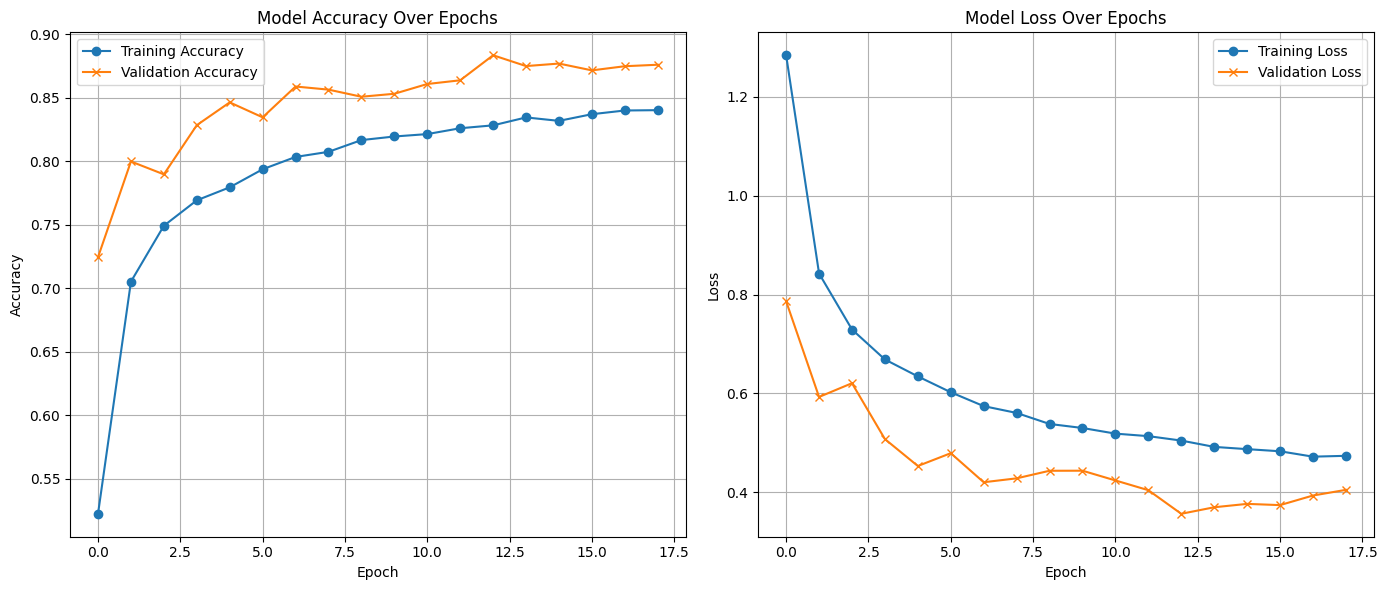

268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


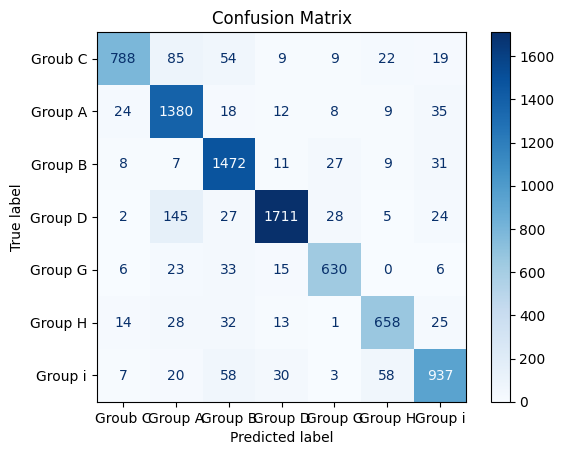

In [ ]:

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

increase batch size
decrease DropOut

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 100, 100
data_dir = "/content/experience 1"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=25),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1373/1373 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.4061 - loss: 1.5481 - val_accuracy: 0.6719 - val_loss: 0.9227
Epoch 2/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.7056 - loss: 0.8330 - val_accuracy: 0.8127 - val_loss: 0.5371
Epoch 3/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.7633 - loss: 0.6734 - val_accuracy: 0.8316 - val_loss: 0.5053
Epoch 4/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 45s 33ms/step - accuracy: 0.7935 - loss: 0.5941 - val_accuracy: 0.7983 - val_loss: 0.6047
Epoch 5/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - accuracy: 0.8105 - loss: 0.5517 - val_accuracy: 0.8597 - val_loss: 0.4056
Epoch 6/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.8211 - loss: 0.5227 - val_accuracy: 0.8626 - val_loss: 0.4118
Epoch 7/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 48s 35ms/step - accuracy: 0.8300 - loss: 0.4883 - val_accuracy: 0.8539 - val_loss: 0.4197
Epoch 8/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 78s 32ms/step - accuracy: 0.8361 - loss: 0.47

268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9086 - loss: 0.2695
Train Accuracy: 88.23%
Test Accuracy: 90.87%


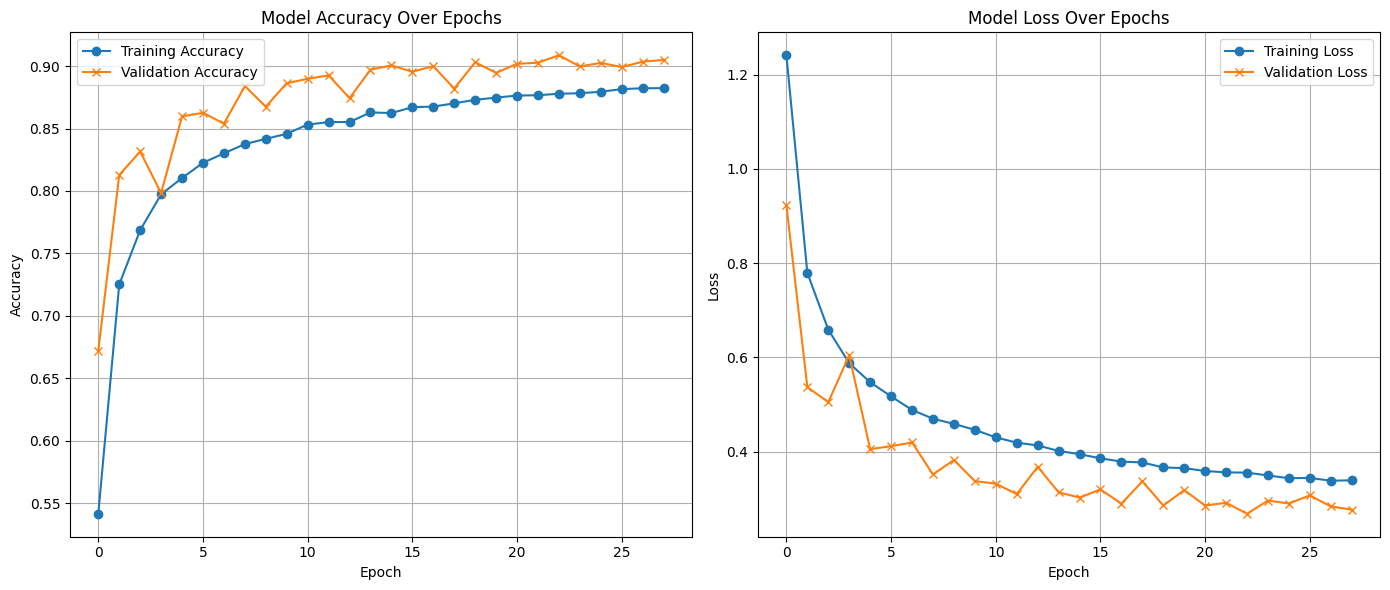

268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


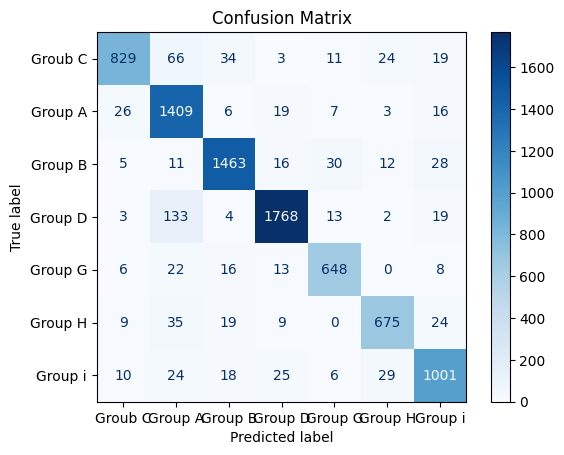

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

### Delete DropOut

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

img_width, img_height = 100, 100
data_dir = "/content/experience 1"

def load_images(data_dir):
    images, labels = [], []
    group_names = sorted(os.listdir(data_dir))
    for label, group_name in enumerate(group_names):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
            for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    for img_file in os.listdir(subfolder_path):
                        img_path = os.path.join(subfolder_path, img_file)
                        try:
                            img = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=(img_width, img_height), color_mode='grayscale'
                            )
                            img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
                            images.append(img_array)
                            labels.append(label)
                        except Exception as e:
                            print(f"Error loading image {img_file} in {group_name}/{subfolder}: {e}")
    return np.array(images), np.array(labels)

images, labels = load_images(data_dir)

num_classes = len(np.unique(labels))
labels = to_categorical(labels, num_classes)

x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('letter_recognition_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=25),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint]
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 52s 34ms/step - accuracy: 0.4291 - loss: 1.4940 - val_accuracy: 0.7344 - val_loss: 0.7692
Epoch 2/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.7473 - loss: 0.7285 - val_accuracy: 0.7736 - val_loss: 0.6723
Epoch 3/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - accuracy: 0.7941 - loss: 0.5872 - val_accuracy: 0.8123 - val_loss: 0.5525
Epoch 4/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.8184 - loss: 0.5236 - val_accuracy: 0.8588 - val_loss: 0.4152
Epoch 5/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 46s 34ms/step - accuracy: 0.8366 - loss: 0.4704 - val_accuracy: 0.8666 - val_loss: 0.3903
Epoch 6/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 44s 32ms/step - accuracy: 0.8441 - loss: 0.4483 - val_accuracy: 0.8632 - val_loss: 0.4131
Epoch 7/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - accuracy: 0.8543 - loss: 0.4127 - val_accuracy: 0.8705 - val_loss: 0.3840
Epoch 8/30
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - accuracy: 0.8592 -

268/268 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8981 - loss: 0.2999
Train Accuracy: 88.97%
Test Accuracy: 89.87%


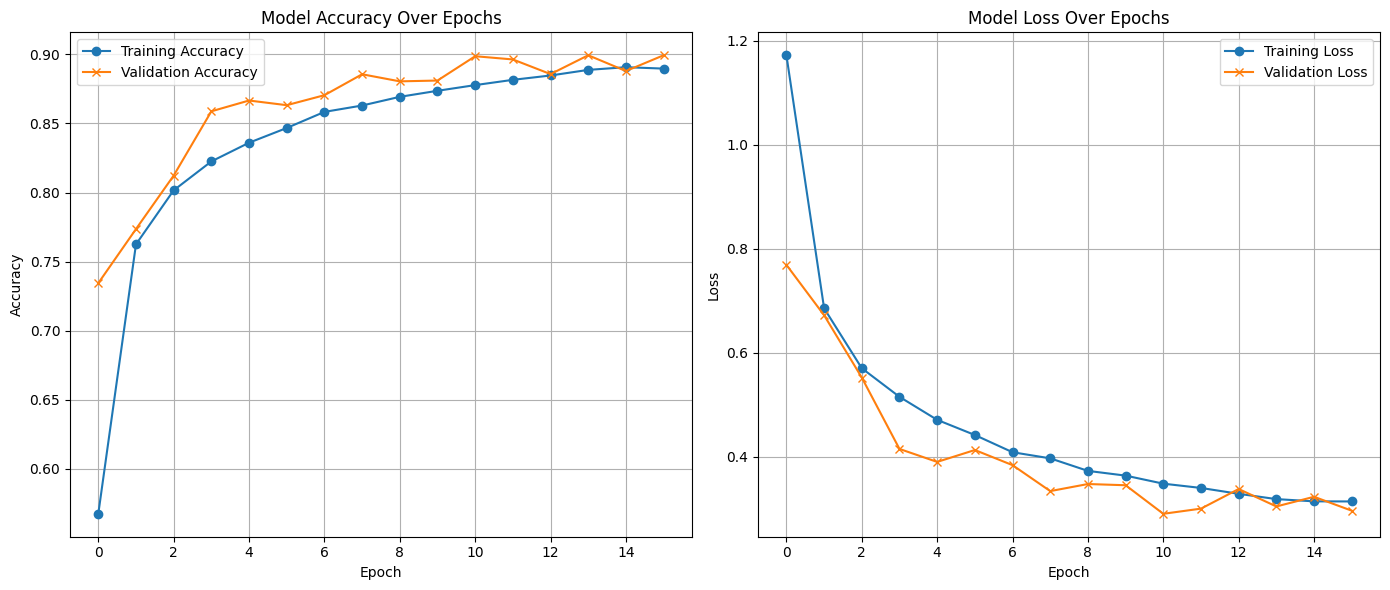

268/268 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


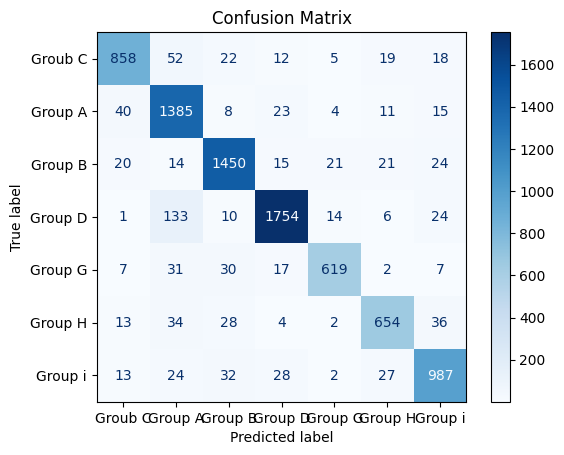

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Train Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)
group_names = sorted(os.listdir(data_dir))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=group_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
model.save('cnn1_model.keras')


In [ ]:
import os
data_dir = "/content/experience 1"
def count_images(data_dir):
    group_counts = {}
    for group_name in sorted(os.listdir(data_dir)):
        group_path = os.path.join(data_dir, group_name)
        if os.path.isdir(group_path):
           total_images = 0
           for subfolder in os.listdir(group_path):
                subfolder_path = os.path.join(group_path, subfolder)
                if os.path.isdir(subfolder_path):
                    num_images = len(os.listdir(subfolder_path))
                    total_images += num_images
                    print(f"num of pic{group_name}/{subfolder}: {num_images}")
                    group_counts[group_name] = total_images
    return group_counts

group_counts = count_images(data_dir)
print("\nTotal number:", group_counts)

num of picGroub C/Zin_End: 464
num of picGroub C/Zal_Isolated: 474
num of picGroub C/Dal_Isolated: 472
num of picGroub C/Raa_Isolated: 476
num of picGroub C/Raa_End: 475
num of picGroub C/Zin_Isolated: 479
num of picGroub C/Dal_End: 480
num of picGroub C/Waw_Isolated: 464
num of picGroub C/Waw_End: 456
num of picGroub C/Zal_End: 476
num of picGroup A/Taa_Isolated: 467
num of picGroup A/Thaa_End: 475
num of picGroup A/Taa_Middle: 462
num of picGroup A/Baa_Start: 473
num of picGroup A/Taa_End: 469
num of picGroup A/Thaa_Isolated: 457
num of picGroup A/Taa_Start: 471
num of picGroup A/Non_Isolated: 466
num of picGroup A/Thaa_Middle: 467
num of picGroup A/Baa_End: 467
num of picGroup A/Thaa_Start: 480
num of picGroup A/Baa_Middle: 460
num of picGroup A/Non_Start: 468
num of picGroup A/Non_Middle: 460
num of picGroup A/Baa_Isolated: 468
num of picGroup A/Non_End: 468
num of picGroup B/Gen_Middle: 458
num of picGroup B/Haa_Isolated: 477
num of picGroup B/Gen_Isolated: 920
num of picGroup B/H